In [1]:

import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
from stress_risk.utils.data import add_cond2df
import pandas as pd

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/nilearn/glm/__init__.py:55: FutureWarning: The nilearn.glm module is experimental. It may change in any future release of Nilearn.
  warn('The nilearn.glm module is experimental. '
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#df = pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates','full_params_bambi1_NLC1.csv')) # risky task params only from session 1 for probir, mean 
df_probit_params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-1_subseswise_params.csv')
df_decod_acc = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_accuracy_allSub_allSes.csv')
df_decod_sd = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_sd_allSub_allSes.csv')

df_decod = df_decod_acc.set_index(['subject','session']).join(df_decod_sd.set_index(['subject','session']))


In [ ]:
df = df_probit_params.set_index(['subject','session']).join(df_decod.set_index(['subject','session']))


In [19]:
df = add_cond2df(df)

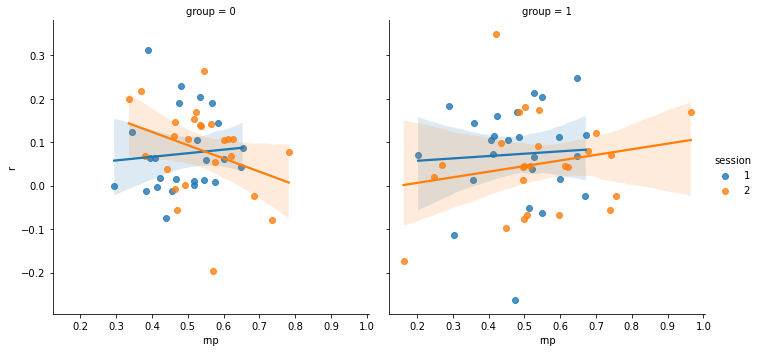

In [21]:
from scipy import stats
y = 'r'
x = 'rnp'
c = np.round(stats.pearsonr(df[x],df[y]), 3)

sns.lmplot(x=x, y=y, data = df.reset_index(), hue='session', col='group')
#plt.title(f'corr: r = {c[0]}, p = {c[1]}')


In [70]:
df_decod = add_cond2df(df_decod)

In [75]:
df_decod


r        sd  group
subject session                           
1       1        0.061686  0.002559      0
        2        0.104811  0.003009      0
2       1        0.013186  0.004608      0
        2       -0.024392  0.005569      0
3       1        0.037224  0.005096      1
...                   ...       ...    ...
58      2        0.170520  0.004372      1
59      1        0.313141  0.002066      0
        2        0.145500  0.003627      0
61      1        0.144704  0.003098      0
        2        0.106332  0.003868      0

[100 rows x 3 columns]

(array([1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
        0., 2., 0., 3., 0., 1., 2., 0., 0., 1., 0., 3., 0., 1., 1., 2., 4.,
        3., 0., 4., 3., 4., 0., 0., 0., 2., 1., 0., 1., 2., 1., 3., 0., 1.,
        1., 0., 4., 1., 3., 1., 1., 2., 0., 4., 2., 3., 3., 2., 0., 1., 2.,
        1., 1., 0., 0., 1., 4., 0., 0., 0., 0., 2., 1., 0., 1., 2., 0., 0.,
        1., 2., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1.]),
 array([0.00142219, 0.00146533, 0.00150848, 0.00155163, 0.00159478,
        0.00163793, 0.00168107, 0.00172422, 0.00176737, 0.00181052,
        0.00185366, 0.00189681, 0.00193996, 0.00198311, 0.00202626,
        0.0020694 , 0.00211255, 0.0021557 , 0.00219885, 0.002242  ,
        0.00228514, 0.00232829, 0.00237144, 0.00241459, 0.00245774,
        0.00250088, 0.00254403, 0.00258718, 0.00263033, 0.00267348,
        0.00271662, 0.00275977, 0.00280292, 0.00284607, 0.00288921,
        0.00293236, 0.00297551, 0.00301866, 0.00306181, 0.00310495,
      

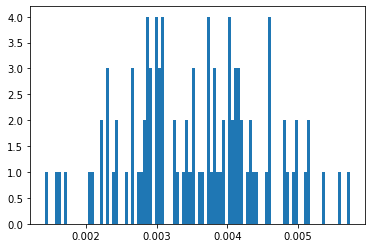

In [79]:
plt.hist(df_decod['sd'], bins=100)

In [72]:
df_decod.groupby(['session', 'group']).apply(lambda d: pingouin.ttest(d['sd'], 0.0))

T  dof alternative         p-val       CI95%  \
session group                                                                
1       0     T-test  20.279197   24   two-sided  1.307309e-16  [0.0, 0.0]   
        1     T-test  19.810416   24   two-sided  2.222968e-16  [0.0, 0.0]   
2       0     T-test  18.692618   24   two-sided  8.257426e-16  [0.0, 0.0]   
        1     T-test  16.984304   24   two-sided  7.049823e-15  [0.0, 0.0]   

                       cohen-d       BF10  power  
session group                                     
1       0     T-test  4.055839  3.757e+13    1.0  
        1     T-test  3.962083  2.264e+13    1.0  
2       0     T-test  3.738524  6.483e+12    1.0  
        1     T-test  3.396861  8.411e+11    1.0

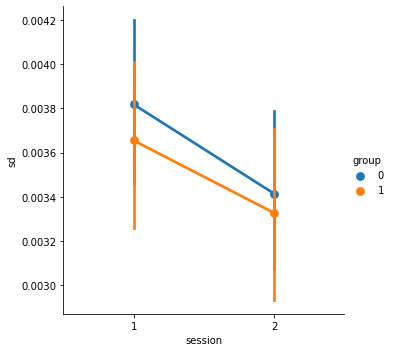

In [76]:
sns.catplot(data=df_decod.reset_index(), x='session', y='sd', hue='group', kind='point', errorbar='se')

In [58]:
bambi.Model(df_decod, 'r ~ session*group + (session|subject)')

ModuleNotFoundError: No module named 'bambi'

In [32]:
import pingouin

/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [77]:
pingouin.mixed_anova(df_decod.reset_index(), dv='sd', within='session', between='group', subject='subject')

,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,3.901314e-07,1,48,3.901314e-07,0.409377,0.525328,0.008457,NaN
1,session,3.339360e-06,1,48,3.339360e-06,4.111728,0.048158,0.078902,1.0
2,Interaction,3.616549e-08,1,48,3.616549e-08,0.044530,0.833763,0.000927,NaN


In [35]:

pingouin.mixed_anova

<function pingouin.parametric.mixed_anova(data=None, dv=None, within=None, subject=None, between=None, correction='auto', effsize='np2')>

In [43]:
old_rnp = pd.read_csv('/Users/mrenke/git/stress_risk/stress_risk/subject_selection/subject_stats.tsv', sep='\t')

In [45]:
old_rnp.head()

,subject,r,rnp
0,1,0.220240,0.609986
1,2,0.105622,0.542685
2,3,-0.077133,0.499765
3,4,-0.014096,0.389723
4,5,0.116511,0.571540


In [47]:
df_decod.loc[(slice(None), 1), :].head()

,,r,group
subject,session,,
1,1,0.061686,0
2,1,0.013186,0
3,1,0.037224,1
4,1,0.106003,1
5,1,0.189829,0


In [49]:

df_decod.describe()

,r,group
count,100.000000,100.000000
mean,0.069600,0.500000
std,0.104185,0.502519
min,-0.264168,0.000000
25%,0.009747,0.000000
50%,0.069086,0.500000
75%,0.139585,1.000000
max,0.349611,1.000000


In [50]:
old_rnp.describe()

,subject,r,rnp
count,51.000000,51.000000,51.000000
mean,41.568627,0.099974,0.484192
std,44.285101,0.127719,0.116897
min,1.000000,-0.212698,0.158412
25%,15.000000,0.003090,0.409671
50%,30.000000,0.127057,0.499765
75%,42.500000,0.203605,0.559747
max,165.000000,0.350202,0.673844


In [52]:
df_decod

r  group
subject session                 
1       1        0.061686      0
        2        0.104811      0
2       1        0.013186      0
        2       -0.024392      0
3       1        0.037224      1
...                   ...    ...
58      2        0.170520      1
59      1        0.313141      0
        2        0.145500      0
61      1        0.144704      0
        2        0.106332      0

[100 rows x 2 columns]

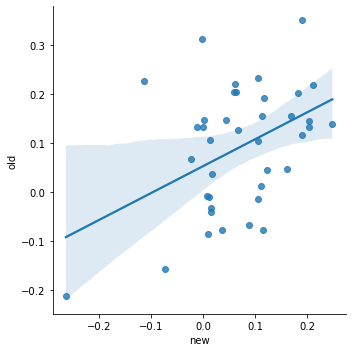

In [57]:
tmp = pd.concat((df_decod.xs(1, 0, 'session'), old_rnp.set_index('subject')),
           keys=['new', 'old'], names=['type'])

tmp = tmp.unstack('type')['r']

sns.lmplot(data=tmp, x='new', y='old')

In [84]:
pdf = pd.read_csv('/Users/mrenke/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-01/func/sub-01_ses-1_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv', sep='\t', index_col=0)

In [85]:
pdf

,0.0,0.006006006151437759,0.012012012302875519,0.018018018454313278,0.024024024605751038,0.030030030757188797,0.036036036908626556,0.042042043060064316,0.048048049211502075,0.054054055362939835,...,5.945945739746094,5.95195198059082,5.957957744598389,5.963963985443115,5.969969749450684,5.97597599029541,5.9819817543029785,5.987987995147705,5.993993759155273,6.0
trial_nr,,,,,,,,,,,,,,,,,,,,,
1,1.831006e-11,2.076765e-11,2.354576e-11,2.668491e-11,3.022967e-11,3.423380e-11,3.875175e-11,4.384854e-11,4.959601e-11,5.607629e-11,...,1.398868e-09,1.205568e-09,1.038187e-09,8.934176e-10,7.682961e-10,6.602140e-10,5.669211e-10,4.864845e-10,4.171548e-10,3.574872e-10
2,6.705228e-12,7.526708e-12,8.443158e-12,9.466570e-12,1.060659e-11,1.187773e-11,1.329309e-11,1.486894e-11,1.662145e-11,1.857031e-11,...,5.236525e-10,4.545824e-10,3.942376e-10,3.415488e-10,2.956129e-10,2.555975e-10,2.207966e-10,1.905420e-10,1.642775e-10,1.415037e-10
3,1.120548e-13,1.246329e-13,1.385340e-13,1.538823e-13,1.708371e-13,1.895212e-13,2.101204e-13,2.328094e-13,2.577988e-13,2.852875e-13,...,2.567537e-12,2.126161e-12,1.759478e-12,1.454880e-12,1.202169e-12,9.926566e-13,8.190826e-13,6.753648e-13,5.564901e-13,4.582315e-13
4,3.025016e-09,3.487195e-09,4.017046e-09,4.623733e-09,5.318312e-09,6.112379e-09,7.019864e-09,8.055932e-09,9.237863e-09,1.058544e-08,...,6.894202e-10,5.734188e-10,4.764993e-10,3.955988e-10,3.281331e-10,2.719489e-10,2.251716e-10,1.862869e-10,1.539807e-10,1.271724e-10
5,4.085682e-11,4.602776e-11,5.181995e-11,5.830008e-11,6.554254e-11,7.364200e-11,8.267673e-11,9.276609e-11,1.040105e-10,1.165431e-10,...,2.644175e-08,2.201686e-08,1.831064e-08,1.520926e-08,1.261739e-08,1.045476e-08,8.652235e-09,7.151971e-09,5.904635e-09,4.869189e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2.793660e-04,2.847022e-04,2.900429e-04,2.954297e-04,3.007881e-04,3.061781e-04,3.115697e-04,3.169692e-04,3.223540e-04,3.277602e-04,...,4.843554e-05,4.674091e-05,4.508906e-05,4.347966e-05,4.191108e-05,4.038675e-05,3.890124e-05,3.745551e-05,3.604921e-05,3.468405e-05
117,5.613414e-08,5.938364e-08,6.279631e-08,6.638081e-08,7.014420e-08,7.409608e-08,7.824434e-08,8.259459e-08,8.715744e-08,9.193308e-08,...,1.471060e-07,1.398564e-07,1.329195e-07,1.262765e-07,1.199216e-07,1.138379e-07,1.080199e-07,1.024649e-07,9.715996e-08,9.209315e-08
118,2.673982e-06,2.751884e-06,2.831450e-06,2.912696e-06,2.995449e-06,3.079708e-06,3.165949e-06,3.253812e-06,3.343093e-06,3.434404e-06,...,2.993611e-05,2.835419e-05,2.684848e-05,2.541420e-05,2.404847e-05,2.274780e-05,2.151222e-05,2.033569e-05,1.921881e-05,1.815662e-05


<AxesSubplot:>

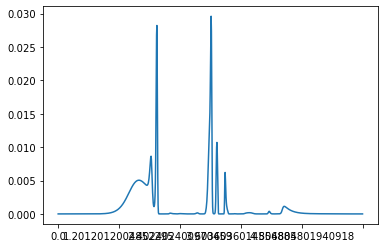

In [87]:
pdf.loc[1].plot()

In [89]:
np.trapz(pdf.loc[1], pdf.columns.astype(float))

0.006006009340978554

In [90]:
sum(pdf.loc[1])

1.0000000676532885

In [93]:
np.trapz(pdf, pdf.columns.astype(float))[:, np.newaxis]

(120,)

In [97]:
np.trapz(pdf, pdf.columns.astype(float))[:, np.newaxis]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],